In [ ]:
# Import libraries

from pathlib import Path
import numpy as np
import nibabel as nib
import pandas as pd
from scipy import stats
import os
import csv
import re
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder
from itertools import combinations
from sklearn.pipeline import make_pipeline

In [ ]:
def check_shape_and_affine(diff_image, seg_nuclei_image, seg_fsv_image):

    """
    Compares diff_image, seg_nuclei_image and seg_fsv_image to each other. Checks the shape and affines, and if they are not the same, align the affine of seg_nuclei_image and seg_fsv_image to diff_image.
    If there is a shape mismatch --> raise ValueError
    If there is an affine mismatch --> align affine such that seg_nuclei_image and seg_fsv_image have the same affine as diff_image
    
    Input:
    - diff_image: nib.load(str(diff_path))
    - seg_nuclei_image: nib.load(str(seg_nuclei_path))
    - seg_fsv_image: nib.load(str(seg_fsv_path))

    Output:
    - Corrected seg_nuclei_image and seg_fsv_image
    """

    same_shape_nuclei = (diff_image.shape == seg_nuclei_image.shape)
    same_affine_nuclei = np.allclose(diff_image.affine, seg_nuclei_image.affine)
    same_shape_fsv = (diff_image.shape == seg_fsv_image.shape)
    same_affine_fsv = np.allclose(diff_image.affine, seg_fsv_image.affine)
    
    if not ((same_shape_nuclei) and (same_shape_fsv)):
        raise ValueError(f"Shape mismatch")

    if not (same_affine_nuclei):
        print(f"Affine mismatch (nuclei) --> reorienting")

        # Given this affine: what axis corresponds to LR, AP, IS (ornt representation)
        seg_ornt = nib.orientations.io_orientation(seg_nuclei_image.affine)

        # Given this affine: give me the coordinate system and the corresponding ornt representation
        diff_ax = nib.orientations.aff2axcodes(diff_image.affine) # For instance LAS, RAS, etc...
        target_ornt = nib.orientations.axcodes2ornt(diff_ax)

        # A new ornt that tells you how to re-order/flip
        transform = nib.orientations.ornt_transform(seg_ornt, target_ornt)

        # Apply transform to change voxel indexing
        seg_data = seg_nuclei_image.get_fdata()
        seg_data_reoriented = nib.orientations.apply_orientation(seg_data, transform)

        # Maps new voxel indexes to same world coordinates
        new_affine = seg_nuclei_image.affine @ nib.orientations.inv_ornt_aff(transform, seg_nuclei_image.shape)

        seg_nuclei_image = nib.Nifti1Image(seg_data_reoriented, new_affine, seg_nuclei_image.header)

        same_shape = (diff_image.shape == seg_nuclei_image.shape)
        same_affine = np.allclose(diff_image.affine, seg_nuclei_image.affine)

        if not ((same_shape) and (same_affine)):
              raise ValueError("Still mismatch in affine (or shape) for nuclei")

    if not (same_affine_fsv):
        print(f"Affine mismatch (fsv) --> reorienting")

        # Given this affine: what axis corresponds to LR, AP, IS (ornt representation)
        seg_ornt = nib.orientations.io_orientation(seg_fsv_image.affine)

        # Given this affine: give me the coordinate system and the corresponding ornt representation
        diff_ax = nib.orientations.aff2axcodes(diff_image.affine)
        target_ornt = nib.orientations.axcodes2ornt(diff_ax)

        # A new ornt that tells you how to re-order/flip
        transform = nib.orientations.ornt_transform(seg_ornt, target_ornt)

        # Apply transform to change voxel indexing
        seg_data = seg_fsv_image.get_fdata()
        seg_data_reoriented = nib.orientations.apply_orientation(seg_data, transform)

        # Maps new voxel indexes to same world coordinates
        new_affine = seg_fsv_image.affine @ nib.orientations.inv_ornt_aff(transform, seg_fsv_image.shape)

        seg_fsv_image = nib.Nifti1Image(seg_data_reoriented, new_affine, seg_fsv_image.header)

        same_shape = (diff_image.shape == seg_fsv_image.shape)
        same_affine = np.allclose(diff_image.affine, seg_fsv_image.affine)

        if not ((same_shape) and (same_affine)):
              raise ValueError("Still mismatch in affine (or shape) for fsv")
        
    return seg_nuclei_image, seg_fsv_image

In [ ]:
def extract_statistical_metrics_from_segments(
    diff_image, 
    seg_nuclei_image, 
    seg_fsv_image, 
    nuclei_union_snr_mask_image, 
    fsv_union_snr_mask_image,
    L1_image,
    L2_image,
    L3_image, 
    subj_id, 
    param_name):

    """
    Extracts statistical metrics from the different segments in seg_nuclei_image and seg_fsv_image, but only inside union masks on diff_image

    Input:
    - diff_image: nib.load(str(diff_path))
    - seg_nuclei_image: nib.load(str(seg_nuclei_path))
    - seg_fsv_image: nib.load(str(seg_fsv_path))
    - nuclei_union_snr_mask_image: binary nuclei_union_snr mask. nib.load(str(nuclei_union_snr_mask_path))
    - fsv_union_snr_mask_image: binary fsv_union_snr mask. nib.load(str(fsv_union_snr_mask_path))
    - L1_image: nib.load(str(L1_path))
    - L2_image: nib.load(str(L2_path))
    - L3_image: nib.load(str(L3_path))
    - subj_id: subject ID [string/int/float]
    - param_name: name of parameter (FA, MD,...) [string]

    Output:
    - List of different statistical metrics as well as information about subject, parameter and segment
    """

    # Convert to arrays
    diff_data = diff_image.get_fdata()
    seg_nuclei_data = np.rint(seg_nuclei_image.get_fdata()).astype(np.int32)
    seg_fsv_data = np.rint(seg_fsv_image.get_fdata()).astype(np.int32)

    nuclei_union_snr_mask_data = nuclei_union_snr_mask_image.get_fdata() > 0
    fsv_union_snr_mask_data = fsv_union_snr_mask_image.get_fdata() > 0

    L1_data = L1_image.get_fdata()
    L2_data = L2_image.get_fdata()
    L3_data = L3_image.get_fdata()

    seg_nuclei_data = seg_nuclei_data * nuclei_union_snr_mask_data #labelmap only inside the chosen binary mask
    seg_fsv_data = seg_fsv_data * fsv_union_snr_mask_data

    labels_nuclei = np.unique(seg_nuclei_data)
    labels_fsv = np.unique(seg_fsv_data)

    valid_voxels = (
        np.isfinite(diff_data) & np.isfinite(L1_data) & np.isfinite(L2_data) & np.isfinite(L3_data) & (L1_data >= 0) & (L2_data >= 0) & (L3_data >= 0)
    )

    rows_local = []

    # Iterate through the segments
    for el in labels_nuclei:
        if el == 0:
            continue

        mask_all = (seg_nuclei_data == el)
        mask_valid = mask_all & valid_voxels
        diff_values = diff_data[mask_valid]

        if diff_values.size == 0:
            continue
            
        voxels_total = int(np.sum(mask_all))
        voxels_valid = int(np.sum(mask_valid))
        voxels_invalid = voxels_total - voxels_valid
        percent_voxels_invalid = (voxels_invalid / voxels_total) * 100 if voxels_total > 0 else np.nan

        mean = np.mean(diff_values)
        std = np.std(diff_values)
        median = np.median(diff_values)
        max_val = np.max(diff_values)
        min_val = np.min(diff_values)
        five_percentile = np.percentile(diff_values, 5)
        skewness = stats.skew(diff_values)
        kurtosis = stats.kurtosis(diff_values)

        rows_local.append({
            "Subject": subj_id,
            "Parameter": param_name,
            "Segment": el,
            "Segmentation tool": "nuclei",
            "Voxels total": voxels_total,
            "Voxels valid": voxels_valid,
            "Voxels invalid": voxels_invalid,
            "Percent voxels invalid": percent_voxels_invalid,
            "Mean": mean,
            "Standard deviation": std,
            "Median": median,
            "Maximum value": max_val,
            "Minimum value": min_val,
            "5th percentile": five_percentile,
            "Skewness": skewness,
            "Kurtosis": kurtosis
        })
    
    for el in labels_fsv:
        if el == 0:
            continue

        mask_all = (seg_fsv_data == el)
        mask_valid = mask_all & valid_voxels
        diff_values = diff_data[mask_valid]

        if diff_values.size == 0:
            continue

        voxels_total = int(np.sum(mask_all))
        voxels_valid = int(np.sum(mask_valid))
        voxels_invalid = voxels_total - voxels_valid
        percent_voxels_invalid = (voxels_invalid / voxels_total) * 100 if voxels_total > 0 else np.nan

        mean = np.mean(diff_values)
        std = np.std(diff_values)
        median = np.median(diff_values)
        max_val = np.max(diff_values)
        min_val = np.min(diff_values)
        five_percentile = np.percentile(diff_values, 5)
        skewness = stats.skew(diff_values)
        kurtosis = stats.kurtosis(diff_values)

        rows_local.append({
            "Subject": subj_id,
            "Parameter": param_name,
            "Segment": el,
            "Segmentation tool": "fsv",
            "Voxels total": voxels_total,
            "Voxels valid": voxels_valid,
            "Voxels invalid": voxels_invalid,
            "Percent voxels invalid": percent_voxels_invalid,
            "Mean": mean,
            "Standard deviation": std,
            "Median": median,
            "Maximum value": max_val,
            "Minimum value": min_val,
            "5th percentile": five_percentile,
            "Skewness": skewness,
            "Kurtosis": kurtosis
        })

    return rows_local

In [ ]:
def extract_diffusion_stats_from_segments(path_to_folder, nuclei_union_snr_mask_filename, fsv_union_snr_mask_filename):

    """"
    Extracts statistical metrics from the different segments in the segment map for every diffusion file and every subject in the path "path_to_folder"
    
    Input:
    - path_to_folder: the path to the folder [string]
    - nuclei_union_snr_mask_filename: filename of chosen nuclei_union_snr mask [string]
    - fsv_union_snr_mask_filename: filename of chosen fsv_union_snr mask [string]

    Output:
    - csv with all the information about subject, parameter, segment, statistical metrics etc.
    """

    parent_dir = Path(path_to_folder)

    # Iterate through the subject folders
    for subj_dir in sorted ([p for p in parent_dir.iterdir() if p.is_dir()]): # Iterate through all folders in parent_dir, sorted alphabetically
        subj_id = subj_dir.name
        seg_nuclei_path = subj_dir / f"{subj_id}_nuclei_dwi-space.nii.gz"
        seg_fsv_path = subj_dir / f"{subj_id}_fsv_dwi-space.nii.gz"

        nuclei_union_snr_mask_path = subj_dir / nuclei_union_snr_mask_filename
        fsv_union_snr_mask_path = subj_dir / fsv_union_snr_mask_filename
        
        orig_seg_nuclei_image = nib.load(str(seg_nuclei_path))
        orig_seg_fsv_image = nib.load(str(seg_fsv_path))

        nuclei_union_snr_mask_image = nib.load(str(nuclei_union_snr_mask_path))
        fsv_union_snr_mask_image = nib.load(str(fsv_union_snr_mask_path))

        rows = []

        diff_files = sorted(f for f in subj_dir.glob("dti_epic_denoised_eddy_dti_*.nii.gz") if not any(x in f.name for x in ["tensor", "V1", "V2", "V3"]))

        L1_path = subj_dir / "dti_epic_denoised_eddy_dti_L1.nii.gz"
        L2_path = subj_dir / "dti_epic_denoised_eddy_dti_L2.nii.gz"
        L3_path = subj_dir / "dti_epic_denoised_eddy_dti_L3.nii.gz"

        L1_image = nib.load(str(L1_path))
        L2_image = nib.load(str(L2_path))
        L3_image = nib.load(str(L3_path))

        # Iterate through the diffusion files
        for diff_path in diff_files:
            param_name = diff_path.name.replace(".nii.gz", "").split("_")[-1]
            diff_image = nib.load(str(diff_path))

            seg_nuclei_image_correct, seg_fsv_image_correct = check_shape_and_affine(diff_image, orig_seg_nuclei_image, orig_seg_fsv_image)
            nuclei_union_snr_mask_image_correct, fsv_union_snr_mask_image_correct = check_shape_and_affine(diff_image, nuclei_union_snr_mask_image, fsv_union_snr_mask_image)

            rows_local = extract_statistical_metrics_from_segments(
                diff_image, 
                seg_nuclei_image_correct, 
                seg_fsv_image_correct, 
                nuclei_union_snr_mask_image_correct, 
                fsv_union_snr_mask_image_correct,
                L1_image,
                L2_image,
                L3_image, 
                subj_id, 
                param_name)

            rows.extend(rows_local)
        
        df = pd.DataFrame(rows)
        df.to_csv(subj_dir / "Statistical metrics for different diffusion parameters_function_updated_only_physical_voxels.csv", index = False, float_format="%.5f")

In [273]:
extract_diffusion_stats_from_segments("/home/thientn/MASTEROPPGAVE/IMPARK/", "seg_nuclei_union_SNR_mask_b0_thr80.nii.gz", "seg_FSV_union_SNR_mask_b0_thr100.nii.gz")

Affine mismatch (nuclei) --> reorienting
Affine mismatch (nuclei) --> reorienting
Affine mismatch (nuclei) --> reorienting
Affine mismatch (nuclei) --> reorienting
Affine mismatch (nuclei) --> reorienting
Affine mismatch (nuclei) --> reorienting
Affine mismatch (nuclei) --> reorienting
Affine mismatch (nuclei) --> reorienting
Affine mismatch (fsv) --> reorienting
Affine mismatch (nuclei) --> reorienting
Affine mismatch (fsv) --> reorienting
Affine mismatch (nuclei) --> reorienting
Affine mismatch (fsv) --> reorienting
Affine mismatch (nuclei) --> reorienting
Affine mismatch (fsv) --> reorienting
Affine mismatch (nuclei) --> reorienting
Affine mismatch (fsv) --> reorienting
Affine mismatch (nuclei) --> reorienting
Affine mismatch (fsv) --> reorienting
Affine mismatch (nuclei) --> reorienting
Affine mismatch (fsv) --> reorienting
Affine mismatch (nuclei) --> reorienting
Affine mismatch (nuclei) --> reorienting
Affine mismatch (nuclei) --> reorienting
Affine mismatch (nuclei) --> reorient

In [ ]:
def make_SNR_mask(raw_file_path_name, threshold_number, volume_indices=None, volume_label=""):

    """
    Make SNR-masks based on a threshold number and specific volumes
    
    Input:
    - raw_file_path_name: file path to raw data [string]
    - threshold_number: threshold value to keep voxel [int/float]
    - volume_indices: list of volumes to use for mean. If None --> uses all volumes
    - volume_label: label for filename [string]

    Output:
    - SNR-mask path
    """
    
    raw_file_path = raw_file_path_name
    threshold = threshold_number

    raw_image = nib.load(raw_file_path)
    raw_data = raw_image.get_fdata()

    if raw_data.ndim != 4:
        raise ValueError("Input image must be 4D (x, y, z, volumes)")
    
    n_volumes = raw_data.shape[3]

    if volume_indices is None:
        volume_indices = np.arange(n_volumes)
    
    raw_data_subset = raw_data[:, :, :, volume_indices]

    # Mean signal across volumes
    mean_signal = np.mean(raw_data_subset, axis = 3)     # 3D-image

    # Creating SNR-mask
    SNR_mask = mean_signal >= threshold                  # 3D-image with True/False

    raw_file_dir = os.path.dirname(raw_file_path)
    threshold_string = str(threshold).replace(".", "p")

    SNR_mask_filename = f"SNR_mask_{volume_label}_threshold_{threshold_string}.nii.gz"
    mean_filename = f"mean_signal_{volume_label}_threshold_{threshold_string}.nii.gz"

    SNR_mask_path = os.path.join(raw_file_dir, SNR_mask_filename)
    mean_path = os.path.join(raw_file_dir, mean_filename)

    SNR_mask_image = nib.Nifti1Image(SNR_mask.astype(np.uint8), raw_image.affine, raw_image.header)
    mean_image = nib.Nifti1Image(mean_signal.astype(np.float32), raw_image.affine, raw_image.header)
    nib.save(SNR_mask_image, SNR_mask_path)
    nib.save(mean_image, mean_path)

    return SNR_mask_path

In [ ]:
b0 = np.asarray([0, 61, 62, 63, 64, 65])
b1000 = np.arange(1, 31)
b2000 = np.arange(31, 61)
all = np.arange(0, 66)

SNR_path_b0_thres70 = make_SNR_mask("/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy.nii.gz", 70, volume_indices=b0, volume_label="b0")
SNR_path_b0_thres75 = make_SNR_mask("/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy.nii.gz", 75, volume_indices=b0, volume_label="b0")
SNR_path_b0_thres80 = make_SNR_mask("/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy.nii.gz", 80, volume_indices=b0, volume_label="b0")
SNR_path_b0_thres90 = make_SNR_mask("/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy.nii.gz", 90, volume_indices=b0, volume_label="b0")
SNR_path_b0_thres100 = make_SNR_mask("/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy.nii.gz", 100, volume_indices=b0, volume_label="b0")
SNR_path_b0_thres120 = make_SNR_mask("/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy.nii.gz", 120, volume_indices=b0, volume_label="b0")
SNR_path_b0_thres150 = make_SNR_mask("/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy.nii.gz", 150, volume_indices=b0, volume_label="b0")
SNR_path_b0_thres200 = make_SNR_mask("/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy.nii.gz", 200, volume_indices=b0, volume_label="b0")
SNR_path_b0_thres350 = make_SNR_mask("/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy.nii.gz", 350, volume_indices=b0, volume_label="b0")
SNR_path_b0_thres500 = make_SNR_mask("/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy.nii.gz", 500, volume_indices=b0, volume_label="b0")
SNR_path_b0_thres650 = make_SNR_mask("/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy.nii.gz", 650, volume_indices=b0, volume_label="b0")
SNR_path_b0_thres800 = make_SNR_mask("/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy.nii.gz", 800, volume_indices=b0, volume_label="b0")

SNR_path_b1000_thres50 = make_SNR_mask("/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy.nii.gz", 50, volume_indices=b1000, volume_label="b1000")
SNR_path_b1000_thres60 = make_SNR_mask("/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy.nii.gz", 60, volume_indices=b1000, volume_label="b1000")
SNR_path_b1000_thres70 = make_SNR_mask("/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy.nii.gz", 70, volume_indices=b1000, volume_label="b1000")
SNR_path_b1000_thres80 = make_SNR_mask("/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy.nii.gz", 80, volume_indices=b1000, volume_label="b1000")
SNR_path_b1000_thres100 = make_SNR_mask("/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy.nii.gz", 100, volume_indices=b1000, volume_label="b1000")
SNR_path_b1000_thres120 = make_SNR_mask("/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy.nii.gz", 120, volume_indices=b1000, volume_label="b1000")
SNR_path_b1000_thres140 = make_SNR_mask("/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy.nii.gz", 140, volume_indices=b1000, volume_label="b1000")

SNR_path_b2000_thres40 = make_SNR_mask("/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy.nii.gz", 40, volume_indices=b2000, volume_label="b2000")
SNR_path_b2000_thres60 = make_SNR_mask("/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy.nii.gz", 60, volume_indices=b2000, volume_label="b2000")
SNR_path_b2000_thres80 = make_SNR_mask("/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy.nii.gz", 80, volume_indices=b2000, volume_label="b2000")
SNR_path_b2000_thres100 = make_SNR_mask("/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy.nii.gz", 100, volume_indices=b2000, volume_label="b2000")
SNR_path_b2000_thres120 = make_SNR_mask("/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy.nii.gz", 120, volume_indices=b2000, volume_label="b2000")

SNR_path_all_thres40 = make_SNR_mask("/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy.nii.gz", 40, volume_indices=all, volume_label="all")
SNR_path_all_thres45 = make_SNR_mask("/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy.nii.gz", 45, volume_indices=all, volume_label="all")
SNR_path_all_thres50 = make_SNR_mask("/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy.nii.gz", 50, volume_indices=all, volume_label="all")
SNR_path_all_thres55 = make_SNR_mask("/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy.nii.gz", 55, volume_indices=all, volume_label="all")
SNR_path_all_thres60 = make_SNR_mask("/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy.nii.gz", 60, volume_indices=all, volume_label="all")
SNR_path_all_thres80 = make_SNR_mask("/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy.nii.gz", 80, volume_indices=all, volume_label="all")
SNR_path_all_thres100 = make_SNR_mask("/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy.nii.gz", 100, volume_indices=all, volume_label="all")
SNR_path_all_thres120 = make_SNR_mask("/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy.nii.gz", 120, volume_indices=all, volume_label="all")


In [ ]:
def make_seg_union_SNR_mask(seg_nuclei_path_name, seg_FSV_path_name, SNR_mask_path_name, label):
    
    """
    Make a mask that is the union between the segment maps (nuclei and FSV) and the SNR-mask
    
    Input:
    - seg_nuclei_path_name: path to nuclei segmentation file [string]
    - seg_FSV_path_name: path to FSV segmentation file [string]
    - SNR_mask_path_name: path to SNR mask [string]
    - label: 

    Output:
    - Paths to the nuclei union SNR-mask, and the fsv union SNR-mask
    - Corrected nuclei and fsv segment maps (correct shape and affine)
    """

    out_dir = os.path.dirname(SNR_mask_path_name)

    SNR_image = nib.load(SNR_mask_path_name)
    seg_nuclei_image = nib.load(seg_nuclei_path_name)
    seg_fsv_image = nib.load(seg_FSV_path_name)
    
    seg_nuclei_image_correct, seg_fsv_image_correct = check_shape_and_affine(SNR_image, seg_nuclei_image, seg_fsv_image)

    # Convert to arrays
    SNR = np.asanyarray(SNR_image.dataobj)
    nuclei = np.asanyarray(seg_nuclei_image_correct.dataobj)
    FSV = np.asanyarray(seg_fsv_image_correct.dataobj)

    SNR_bool = SNR > 0.5          # 3D True/False
    nuclei_all_seg = nuclei > 0   # 3D True/False
    FSV_all_seg = FSV > 0         # 3D True/False

    mask_nuclei_union_SNR = nuclei_all_seg & SNR_bool  # 3D True/False
    mask_FSV_union_SNR = FSV_all_seg & SNR_bool        # 3D True/False

    mask_nuclei_union_SNR_path = os.path.join(out_dir, f"seg_nuclei_union_SNR_mask_{label}.nii.gz")
    mask_FSV_union_SNR_path = os.path.join(out_dir, f"seg_FSV_union_SNR_mask_{label}.nii.gz")

    mask_nuclei_union_SNR_image = nib.Nifti1Image(mask_nuclei_union_SNR.astype(np.uint8), SNR_image.affine, SNR_image.header)
    mask_FSV_union_SNR_image = nib.Nifti1Image(mask_FSV_union_SNR.astype(np.uint8), SNR_image.affine, SNR_image.header)

    nib.save(mask_nuclei_union_SNR_image, mask_nuclei_union_SNR_path)
    nib.save(mask_FSV_union_SNR_image, mask_FSV_union_SNR_path)    

    return mask_nuclei_union_SNR_path, mask_FSV_union_SNR_path, seg_nuclei_image_correct, seg_fsv_image_correct

In [ ]:
def load_if_path(x):

    """
    Returns the image of "x". 
    If it is a string --> return the image of it
    If it is an image --> return as it is
    
    Input:
    - x: can be an image, a filepath

    Output:
    - The image of x (nib.load)
    """
    return nib.load(x) if isinstance(x, str) else x

def analyze_minmax_with_masks(FA_path, MD_path, L1_path, L2_path, L3_path, segment, mask_union, name="SEG"):

    """
    Gives min/max of FA/MD and number of negative eigenvalues. Every file must have same shape and affine
    
    Input:
    - FA_path: path to FA file
    - MD_path: path to MD file
    - (L1/L2/L3)_path: path to (L1/L2/L3) file
    - segment: segment image/file path (nuclei or fsv)
    - mask_union: path to segment union SNR mask

    Output:
    - dictionary with min/max values of FA/MD and the number of negative eigenvalues (L1/L2/L3)
    """
    
    FA_image = nib.load(FA_path)
    MD_image = nib.load(MD_path)
    L1_image = nib.load(L1_path)
    L2_image = nib.load(L2_path)
    L3_image = nib.load(L3_path)

    seg_image  = load_if_path(segment)     # <-- seg can be a path or nib image
    mask_image = load_if_path(mask_union)  # <-- mask can be a path or nib image

    if not np.allclose(FA_image.affine, mask_image.affine, atol=1e-4):
        raise RuntimeError(f"[{name}] Affine mismatch between FA and mask.")

    FA = np.asanyarray(FA_image.dataobj).astype(np.float32)
    MD = np.asanyarray(MD_image.dataobj).astype(np.float32)
    L1 = np.asanyarray(L1_image.dataobj).astype(np.float32)
    L2 = np.asanyarray(L2_image.dataobj).astype(np.float32)
    L3 = np.asanyarray(L3_image.dataobj).astype(np.float32)

    seg_arr  = np.rint(np.asanyarray(seg_image.dataobj)).astype(np.int32)
    mask_arr = np.asanyarray(mask_image.dataobj) > 0 # Boolean 

    # Shape check
    shp = FA.shape[:3] # The 3 first dimensions
    for nm, a in [("MD", MD), ("L1", L1), ("L2", L2), ("L3", L3), ("SEG", seg_arr), ("MASK", mask_arr)]:
        if a.shape[:3] != shp:
            raise ValueError(f"[{name}] Shape mismatch: FA {shp} vs {nm} {a.shape[:3]}")
    
    neg_any_global = (L1 < 0) | (L2 < 0) | (L3 < 0)

    if not np.any(mask_arr):
        print(f"\n{name}: mask is empty -> stopping.")
        return {
            "name": name,
            "voxels_in_mask": 0,
            #"FA_min_global": round(float(np.min(FA)), 2),
            #"FA_max_global": round(float(np.max(FA)), 2),
            #"MD_min_global": round(float(np.min(MD)), 2),
            #"MD_max_global": round(float(np.max(MD)), 2),
            "FA_min_mask": "",
            "FA_max_mask": "",
            "MD_min_mask": "",
            "MD_max_mask": "",
            #"neg_L1_global": int(np.sum(L1 < 0)),
            #"neg_L2_global": int(np.sum(L2 < 0)),
            #"neg_L3_global": int(np.sum(L3 < 0)),
            #"neg_any_global": int(np.sum(neg_any_global)),
            #"neg_L1_mask": "",
            #"neg_L2_mask": "",
            #"neg_L3_mask": "",
            "neg_any_mask": ""
        }

    results = {
        "name": name,
        "voxels_in_mask": int(np.sum(mask_arr)),

        #"FA_min_global": round(float(np.min(FA)), 2),
        #"FA_max_global": round(float(np.max(FA)), 2),
        #"MD_min_global": round(float(np.min(MD)), 2),
        #"MD_max_global": round(float(np.max(MD)), 2),

        "FA_min_mask": round(float(np.min(FA[mask_arr])), 2),
        "FA_max_mask": round(float(np.max(FA[mask_arr])), 2),
        "MD_min_mask": round(float(np.min(MD[mask_arr])), 2),
        "MD_max_mask": round(float(np.max(MD[mask_arr])), 2),

        #"neg_L1_global": int(np.sum(L1 < 0)),
        #"neg_L2_global": int(np.sum(L2 < 0)),
        #"neg_L3_global": int(np.sum(L3 < 0)),
        #"neg_any_global": int(np.sum(neg_any_global)),

        #"neg_L1_mask": int(np.sum((L1 < 0) & mask_arr)),
        #"neg_L2_mask": int(np.sum((L2 < 0) & mask_arr)),
        #"neg_L3_mask": int(np.sum((L3 < 0) & mask_arr)),
        "neg_any_mask": int(np.sum(neg_any_global & mask_arr))
    }

    print(f"{name}: MASK")
    print(f"============================")
    #print(f"FA global min/max: {results['FA_min_global']} / {results['FA_max_global']}")
    #print(f"MD global min/max: {results['MD_min_global']} / {results['MD_max_global']}")
    print(f"FA mask min/max:   {results['FA_min_mask']} / {results['FA_max_mask']}")
    print(f"MD mask min/max:   {results['MD_min_mask']} / {results['MD_max_mask']}")
    #print(f"Neg eig global:    {results['neg_any_global']}")
    print(f"Neg eig in mask:   {results['neg_any_mask']}")

    return results

In [ ]:
mask_nuc_path, mask_fsv_path, seg_nuc_corr, seg_fsv_corr = make_seg_union_SNR_mask(
    seg_nuclei_path_name="/home/thientn/MASTEROPPGAVE/IMPARK/02-0003/02-0003_nuclei_dwi-space.nii.gz",
    seg_FSV_path_name="/home/thientn/MASTEROPPGAVE/IMPARK/02-0003/02-0003_fsv_dwi-space.nii.gz",
    SNR_mask_path_name="/home/thientn/MASTEROPPGAVE/IMPARK/02-0003/SNR_mask_threshold_120.nii.gz"
)

analyze_minmax_with_masks(
    fa_path="/home/thientn/MASTEROPPGAVE/IMPARK/02-0003/dti_epic_denoised_eddy_dti_FA.nii.gz", 
    md_path="/home/thientn/MASTEROPPGAVE/IMPARK/02-0003/dti_epic_denoised_eddy_dti_MD.nii.gz",
    l1_path="/home/thientn/MASTEROPPGAVE/IMPARK/02-0003/dti_epic_denoised_eddy_dti_L1.nii.gz", 
    l2_path="/home/thientn/MASTEROPPGAVE/IMPARK/02-0003/dti_epic_denoised_eddy_dti_L2.nii.gz", 
    l3_path="/home/thientn/MASTEROPPGAVE/IMPARK/02-0003/dti_epic_denoised_eddy_dti_L3.nii.gz",
    seg=seg_nuc_corr,
    mask=mask_nuc_path,
    name="NUCLEI"
)

analyze_minmax_with_masks(
    fa_path="/home/thientn/MASTEROPPGAVE/IMPARK/02-0003/dti_epic_denoised_eddy_dti_FA.nii.gz", 
    md_path="/home/thientn/MASTEROPPGAVE/IMPARK/02-0003/dti_epic_denoised_eddy_dti_MD.nii.gz",
    l1_path="/home/thientn/MASTEROPPGAVE/IMPARK/02-0003/dti_epic_denoised_eddy_dti_L1.nii.gz", 
    l2_path="/home/thientn/MASTEROPPGAVE/IMPARK/02-0003/dti_epic_denoised_eddy_dti_L2.nii.gz", 
    l3_path="/home/thientn/MASTEROPPGAVE/IMPARK/02-0003/dti_epic_denoised_eddy_dti_L3.nii.gz",
    seg=seg_fsv_corr,
    mask=mask_fsv_path,
    name="FSV"
)

In [ ]:
"""
Obtained FA/MD min/max for each mask as well as the total number of voxels and number of voxels with negative eigenvalues in each mask
"""

snr_masks = {
    
    "b0_thr70": SNR_path_b0_thres70,
    "b0_thr75": SNR_path_b0_thres75,
    "b0_thr80": SNR_path_b0_thres80,
    "b0_thr90": SNR_path_b0_thres90,
    "b0_thr100": SNR_path_b0_thres100,
    "b0_thr120": SNR_path_b0_thres120,
    "b0_thr150": SNR_path_b0_thres150,
    "b0_thr200": SNR_path_b0_thres200,
    "b0_thr350": SNR_path_b0_thres350,
    "b0_thr500": SNR_path_b0_thres500,
    "b0_thr650": SNR_path_b0_thres650,
    "b0_thr800": SNR_path_b0_thres800,

    "b1000_thr50": SNR_path_b1000_thres50,
    "b1000_thr60": SNR_path_b1000_thres60,
    "b1000_thr70": SNR_path_b1000_thres70,
    "b1000_thr80": SNR_path_b1000_thres80,
    "b1000_thr100": SNR_path_b1000_thres100,
    "b1000_thr120": SNR_path_b1000_thres120,
    "b1000_thr140": SNR_path_b1000_thres140,

    "b2000_thr40": SNR_path_b2000_thres40,
    "b2000_thr60": SNR_path_b2000_thres60,
    "b2000_thr80": SNR_path_b2000_thres80,
    "b2000_thr100": SNR_path_b2000_thres100,
    "b2000_thr120": SNR_path_b2000_thres120,

    "all_thr40": SNR_path_all_thres40,
    "all_thr45": SNR_path_all_thres45,
    "all_thr50": SNR_path_all_thres50,
    "all_thr55": SNR_path_all_thres55,
    "all_thr60": SNR_path_all_thres60,
    "all_thr80": SNR_path_all_thres80,
    "all_thr100": SNR_path_all_thres100,
    "all_thr120": SNR_path_all_thres120,

}

all_results = []

for label, snr_mask_path in snr_masks.items():

    mask_nuc_path, mask_fsv_path, seg_nuc_corr, seg_fsv_corr = make_seg_union_SNR_mask(
    seg_nuclei_path_name="/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/02_0041_nuclei_dwi-space.nii.gz",
    seg_FSV_path_name="/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/02_0041_fsv_dwi-space.nii.gz",
    SNR_mask_path_name=snr_mask_path,
    label=label  
    )

    res_nuc = analyze_minmax_with_masks(
        FA_path="/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy_dti_FA.nii.gz", 
        MD_path="/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy_dti_MD.nii.gz",
        L1_path="/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy_dti_L1.nii.gz", 
        L2_path="/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy_dti_L2.nii.gz", 
        L3_path="/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy_dti_L3.nii.gz",
        segment=seg_nuc_corr,
        mask_union=mask_nuc_path,
        name=f"NUCLEI_{label}"  
    )

    res_fsv = analyze_minmax_with_masks(
        FA_path="/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy_dti_FA.nii.gz", 
        MD_path="/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy_dti_MD.nii.gz",
        L1_path="/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy_dti_L1.nii.gz", 
        L2_path="/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy_dti_L2.nii.gz", 
        L3_path="/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy_dti_L3.nii.gz",
        segment=seg_fsv_corr,
        mask_union=mask_fsv_path,
        name=f"FSV_{label}"
    )

    all_results.append(res_nuc)
    all_results.append(res_fsv)

csv_path = "/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/snr_mask_analysis_results.csv"

if not all_results:
    raise ValueError("No results were generated.")

keys = all_results[0].keys()

with open(csv_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=keys)
    writer.writeheader()
    writer.writerows(all_results)


Affine mismatch (nuclei) --> reorienting
NUCLEI_b0_thr70: MASK
FA mask min/max:   0.08 / 0.83
MD mask min/max:   0.0 / 0.0
Neg eig in mask:   1
FSV_b0_thr70: MASK
FA mask min/max:   0.0 / 1.22
MD mask min/max:   -0.0 / 0.0
Neg eig in mask:   61
Affine mismatch (nuclei) --> reorienting
NUCLEI_b0_thr75: MASK
FA mask min/max:   0.08 / 0.83
MD mask min/max:   0.0 / 0.0
Neg eig in mask:   1
FSV_b0_thr75: MASK
FA mask min/max:   0.0 / 1.15
MD mask min/max:   -0.0 / 0.0
Neg eig in mask:   54
Affine mismatch (nuclei) --> reorienting
NUCLEI_b0_thr80: MASK
FA mask min/max:   0.08 / 0.83
MD mask min/max:   0.0 / 0.0
Neg eig in mask:   1
FSV_b0_thr80: MASK
FA mask min/max:   0.0 / 1.15
MD mask min/max:   -0.0 / 0.0
Neg eig in mask:   50
Affine mismatch (nuclei) --> reorienting
NUCLEI_b0_thr90: MASK
FA mask min/max:   0.08 / 0.74
MD mask min/max:   0.0 / 0.0
Neg eig in mask:   0
FSV_b0_thr90: MASK
FA mask min/max:   0.0 / 1.15
MD mask min/max:   -0.0 / 0.0
Neg eig in mask:   37
Affine mismatch (nuc

In [ ]:
"""
Compute the percentage of unphysical voxels removed and the percentage of physical voxels removed for each mask
"""

L1_path = "/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy_dti_L1.nii.gz"
L2_path = "/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy_dti_L2.nii.gz"
L3_path = "/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy_dti_L3.nii.gz"

nuclei_path = "/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/02_0041_nuclei_dwi-space.nii.gz"
fsv_path = "/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/02_0041_fsv_dwi-space.nii.gz"

mask_dir = "/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/"
csv_path = "/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/percent_voxels_left_results.csv"

L1_array = np.asanyarray(nib.load(L1_path).dataobj)
L2_array = np.asanyarray(nib.load(L2_path).dataobj)
L3_array = np.asanyarray(nib.load(L3_path).dataobj)

unphysical = (L1_array < 0) | (L2_array < 0) | (L3_array < 0)    # Boolean array. True when at least one eigenvalue is negative
physical = ~unphysical                                           # Boolean array. True when no negative eigenvalues

L1_image = nib.load(L1_path)
nuclei_image = nib.load(nuclei_path)
fsv_image = nib.load(fsv_path)

nuclei_image_correct, fsv_image_correct = check_shape_and_affine(L1_image, nuclei_image, fsv_image)

nuclei_mask = np.asanyarray(nuclei_image_correct.dataobj) > 0   # Boolean array with true/false
fsv_mask = np.asanyarray(fsv_image_correct.dataobj) > 0         # Boolean array with true/false

def baseline_counts(segmentation_mask):                         # Boolean mask of (un)physical voxels inside segmentation. Gives number of (un)physical voxels in segmentation
    return {
        "Unphysical_voxels_before": int(np.sum(segmentation_mask & unphysical)),
        "Physical_voxels_before": int(np.sum(segmentation_mask & physical))
    }

nuclei_baseline_counts = baseline_counts(nuclei_mask)
fsv_baseline_counts = baseline_counts(fsv_mask)
print(nuclei_baseline_counts)
print(fsv_baseline_counts)

results = []

pattern_file = re.compile(r"seg_(nuclei|FSV)_union_SNR_mask_(b0|b1000|b2000|all)_thr(\d+)\.nii\.gz")

mask_files = sorted(
    [f for f in os.listdir(mask_dir) if pattern_file.match(f)],
    key=lambda x: (  # To sort by group 1, then group 2, and then group 3
        pattern_file.match(x).group(1),
        pattern_file.match(x).group(2),
        int(pattern_file.match(x).group(3))
    )
)

for fname in mask_files:
    full_path = os.path.join(mask_dir, fname)
    match = pattern_file.match(fname)
    segment_type = match.group(1)
    snr_type = match.group(2)
    threshold = int(match.group(3))

    segment_snr_mask = np.asanyarray(nib.load(full_path).dataobj) > 0

    if segment_type == "nuclei":
        segment_mask = nuclei_mask 
        baseline = nuclei_baseline_counts
    else:
        segment_mask = fsv_mask    
        baseline = fsv_baseline_counts

    unphysical_voxels_before = baseline["Unphysical_voxels_before"]
    physical_voxels_before = baseline["Physical_voxels_before"]

    unphysical_voxels_after = int(np.sum(segment_snr_mask & unphysical))
    physical_voxels_after = int(np.sum(segment_snr_mask & physical))

    if unphysical_voxels_before > 0:
        percent_unphysical_voxels_removed = 100 * ((unphysical_voxels_before - unphysical_voxels_after) / unphysical_voxels_before) # Vil ha 100%
    else:
        percent_unphysical_voxels_removed = np.nan
    
    if physical_voxels_before > 0:
        percent_physical_voxels_removed = 100 * ((physical_voxels_before - physical_voxels_after) / physical_voxels_before)         # Vil ha 0%
    else:
        percent_physical_voxels_removed = np.nan

    results.append({
        "Filename": fname,
    
        "Percent_unphysical_voxels_removed": percent_unphysical_voxels_removed,

        "Percent_physical_voxels_removed": percent_physical_voxels_removed,
    })

with open(csv_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=results[0].keys())
    writer.writeheader()
    writer.writerows(results)
    

Affine mismatch (nuclei) --> reorienting
{'Unphysical_voxels_before': 6, 'Physical_voxels_before': 706}
{'Unphysical_voxels_before': 1105, 'Physical_voxels_before': 452878}


/tmp/ipykernel_1333091/3354224520.py:43: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_plot.groupby("segmentation", group_keys=False).apply(lambda g: g.nsmallest(3, "dist2"))


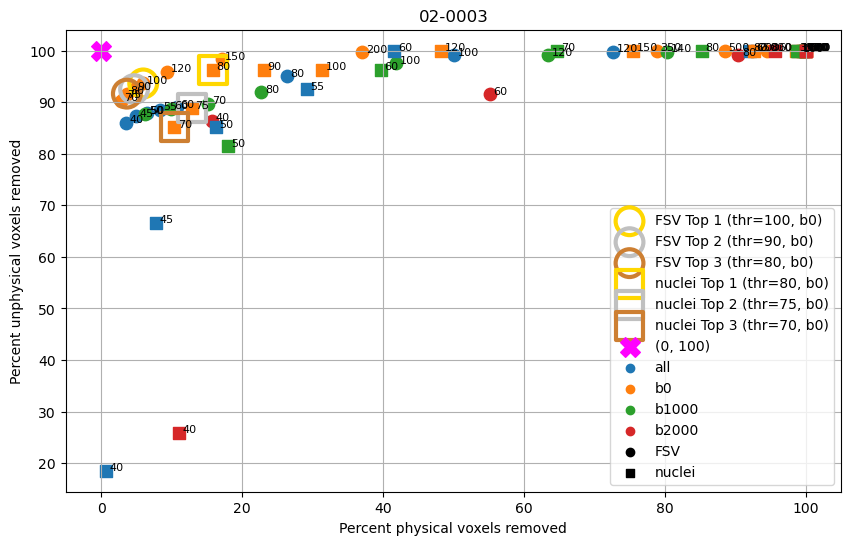

In [ ]:
"""
Plot percentage of unphysical voxels vs. percentage of physical voxels
"""

csv_path = "/home/thientn/MASTEROPPGAVE/IMPARK/02-0003/percent_voxels_left_results.csv"
df = pd.read_csv(csv_path)

file_pattern = re.compile(r"seg_(nuclei|FSV)_union_SNR_mask_(b0|b1000|b2000|all)_thr(\d+)\.nii\.gz")

def parse_filename(fname):
    m = file_pattern.match(fname)
    
    return pd.Series([m.group(1), m.group(2), int(m.group(3))])

df[["segmentation", "snr_type", "threshold"]] = df["Filename"].apply(parse_filename)

df = df.dropna(subset=["segmentation", "snr_type", "threshold"]).copy()
df["threshold"] = df["threshold"].astype(int)

colors = {
    "all": "tab:blue",
    "b0": "tab:orange",
    "b1000": "tab:green",
    "b2000": "tab:red",
}

markers = {
    "FSV": "o",
    "nuclei": "s"
}

plt.figure(figsize=(10, 6))

df_plot = df.dropna(subset=["Percent_physical_voxels_removed", "Percent_unphysical_voxels_removed"]).copy()

# Calculates distance to (0,100)
df_plot["dist2"] = (
    (df_plot["Percent_physical_voxels_removed"])**2 + (df_plot["Percent_unphysical_voxels_removed"] - 100)**2
)

top3_each = (
    df_plot.groupby("segmentation", group_keys=False).apply(lambda g: g.nsmallest(3, "dist2"))
)

for _, row in df_plot.iterrows():
    x = row["Percent_physical_voxels_removed"]
    y = row["Percent_unphysical_voxels_removed"]

    snr = row["snr_type"]
    seg = row["segmentation"]
    thr = row["threshold"]

    plt.scatter(x, y, color=colors[snr], marker=markers[seg], s=80)

    plt.text(x + 0.5, y, str(thr), fontsize=8)


highlight_colors = ["gold", "silver", "#cd7f32"]

for seg_type in ["FSV", "nuclei"]:
    top_seg = top3_each[top3_each["segmentation"] == seg_type].reset_index(drop=True)

    for i, row in top_seg.iterrows():
        x = row["Percent_physical_voxels_removed"]
        y = row["Percent_unphysical_voxels_removed"]
        label = f"{seg_type} Top {i + 1} (thr={row["threshold"]}, {row["snr_type"]})"
        plt.scatter(
            x, y, 
            s = 400, 
            facecolors = "none",
            edgecolors = highlight_colors[i],
            marker=markers[seg_type],
            linewidths = 3,
            label = label
        )

plt.scatter(
    0, 100,
    color = "magenta",
    marker = "X",
    s = 200,
    label = "(0, 100)"
)

for snr, color in colors.items():
    plt.scatter([], [], color=color, marker="o", label=snr)

for seg, marker in markers.items():
    plt.scatter([], [], color="black", marker=marker, label=seg)

plt.xlabel("Percent physical voxels removed")
plt.ylabel("Percent unphysical voxels removed")
plt.title("02-0003")
plt.grid(True)
plt.legend()
plt.savefig("02-0003_figure")
plt.show()

/tmp/ipykernel_1333091/4106008374.py:43: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_plot.groupby("segmentation", group_keys=False).apply(lambda g: g.nsmallest(3, "dist2"))


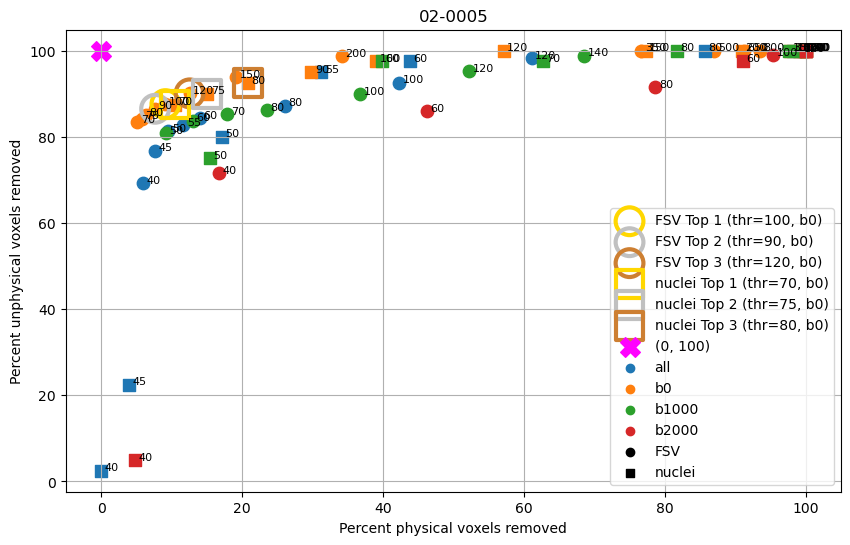

In [ ]:
"""
Plot percentage of unphysical voxels vs. percentage of physical voxels
"""

csv_path = "/home/thientn/MASTEROPPGAVE/IMPARK/02-0005/percent_voxels_left_results.csv"
df = pd.read_csv(csv_path)

file_pattern = re.compile(r"seg_(nuclei|FSV)_union_SNR_mask_(b0|b1000|b2000|all)_thr(\d+)\.nii\.gz")

def parse_filename(fname):
    m = file_pattern.match(fname)
    
    return pd.Series([m.group(1), m.group(2), int(m.group(3))])

df[["segmentation", "snr_type", "threshold"]] = df["Filename"].apply(parse_filename)

df = df.dropna(subset=["segmentation", "snr_type", "threshold"]).copy()
df["threshold"] = df["threshold"].astype(int)

colors = {
    "all": "tab:blue",
    "b0": "tab:orange",
    "b1000": "tab:green",
    "b2000": "tab:red",
}

markers = {
    "FSV": "o",
    "nuclei": "s"
}

plt.figure(figsize=(10, 6))

df_plot = df.dropna(subset=["Percent_physical_voxels_removed", "Percent_unphysical_voxels_removed"]).copy()

# Calculates distance to (0,100)
df_plot["dist2"] = (
    (df_plot["Percent_physical_voxels_removed"])**2 + (df_plot["Percent_unphysical_voxels_removed"] - 100)**2
)

top3_each = (
    df_plot.groupby("segmentation", group_keys=False).apply(lambda g: g.nsmallest(3, "dist2"))
)

for _, row in df_plot.iterrows():
    x = row["Percent_physical_voxels_removed"]
    y = row["Percent_unphysical_voxels_removed"]

    snr = row["snr_type"]
    seg = row["segmentation"]
    thr = row["threshold"]

    plt.scatter(x, y, color=colors[snr], marker=markers[seg], s=80)

    plt.text(x + 0.5, y, str(thr), fontsize=8)


highlight_colors = ["gold", "silver", "#cd7f32"]

for seg_type in ["FSV", "nuclei"]:
    top_seg = top3_each[top3_each["segmentation"] == seg_type].reset_index(drop=True)

    for i, row in top_seg.iterrows():
        x = row["Percent_physical_voxels_removed"]
        y = row["Percent_unphysical_voxels_removed"]
        label = f"{seg_type} Top {i + 1} (thr={row["threshold"]}, {row["snr_type"]})"
        plt.scatter(
            x, y, 
            s = 400, 
            facecolors = "none",
            edgecolors = highlight_colors[i],
            marker=markers[seg_type],
            linewidths = 3,
            label = label
        )

plt.scatter(
    0, 100,
    color = "magenta",
    marker = "X",
    s = 200,
    label = "(0, 100)"
)

for snr, color in colors.items():
    plt.scatter([], [], color=color, marker="o", label=snr)

for seg, marker in markers.items():
    plt.scatter([], [], color="black", marker=marker, label=seg)

plt.xlabel("Percent physical voxels removed")
plt.ylabel("Percent unphysical voxels removed")
plt.title("02-0005")
plt.grid(True)
plt.legend()
plt.savefig("02-0005_figure")
plt.show()

/tmp/ipykernel_1333091/3951353331.py:43: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_plot.groupby("segmentation", group_keys=False).apply(lambda g: g.nsmallest(3, "dist2"))


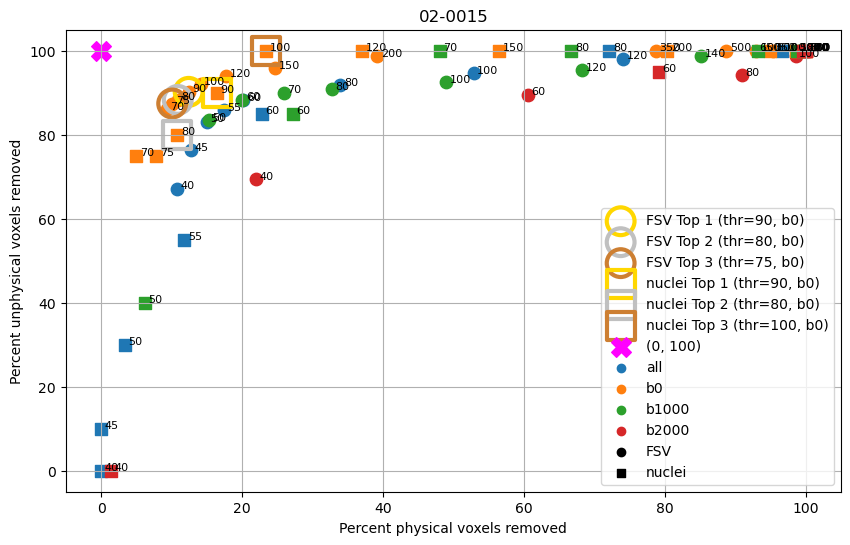

In [ ]:
"""
Plot percentage of unphysical voxels vs. percentage of physical voxels
"""

csv_path = "/home/thientn/MASTEROPPGAVE/IMPARK/02-0015/percent_voxels_left_results.csv"
df = pd.read_csv(csv_path)

file_pattern = re.compile(r"seg_(nuclei|FSV)_union_SNR_mask_(b0|b1000|b2000|all)_thr(\d+)\.nii\.gz")

def parse_filename(fname):
    m = file_pattern.match(fname)
    
    return pd.Series([m.group(1), m.group(2), int(m.group(3))])

df[["segmentation", "snr_type", "threshold"]] = df["Filename"].apply(parse_filename)

df = df.dropna(subset=["segmentation", "snr_type", "threshold"]).copy()
df["threshold"] = df["threshold"].astype(int)

colors = {
    "all": "tab:blue",
    "b0": "tab:orange",
    "b1000": "tab:green",
    "b2000": "tab:red",
}

markers = {
    "FSV": "o",
    "nuclei": "s"
}

plt.figure(figsize=(10, 6))

df_plot = df.dropna(subset=["Percent_physical_voxels_removed", "Percent_unphysical_voxels_removed"]).copy()

# Calculates distance to (0,100)
df_plot["dist2"] = (
    (df_plot["Percent_physical_voxels_removed"])**2 + (df_plot["Percent_unphysical_voxels_removed"] - 100)**2
)

top3_each = (
    df_plot.groupby("segmentation", group_keys=False).apply(lambda g: g.nsmallest(3, "dist2"))
)

for _, row in df_plot.iterrows():
    x = row["Percent_physical_voxels_removed"]
    y = row["Percent_unphysical_voxels_removed"]

    snr = row["snr_type"]
    seg = row["segmentation"]
    thr = row["threshold"]

    plt.scatter(x, y, color=colors[snr], marker=markers[seg], s=80)

    plt.text(x + 0.5, y, str(thr), fontsize=8)


highlight_colors = ["gold", "silver", "#cd7f32"]

for seg_type in ["FSV", "nuclei"]:
    top_seg = top3_each[top3_each["segmentation"] == seg_type].reset_index(drop=True)

    for i, row in top_seg.iterrows():
        x = row["Percent_physical_voxels_removed"]
        y = row["Percent_unphysical_voxels_removed"]
        label = f"{seg_type} Top {i + 1} (thr={row["threshold"]}, {row["snr_type"]})"
        plt.scatter(
            x, y, 
            s = 400, 
            facecolors = "none",
            edgecolors = highlight_colors[i],
            marker=markers[seg_type],
            linewidths = 3,
            label = label
        )

plt.scatter(
    0, 100,
    color = "magenta",
    marker = "X",
    s = 200,
    label = "(0, 100)"
)

for snr, color in colors.items():
    plt.scatter([], [], color=color, marker="o", label=snr)

for seg, marker in markers.items():
    plt.scatter([], [], color="black", marker=marker, label=seg)

plt.xlabel("Percent physical voxels removed")
plt.ylabel("Percent unphysical voxels removed")
plt.title("02-0015")
plt.grid(True)
plt.legend()
plt.savefig("02-0015_figure")
plt.show()

In [ ]:
"""
To find the optimal mask to use in subsequent analysis
"""

base_dir = Path("/home/thientn/MASTEROPPGAVE/IMPARK")
csv_paths = sorted(base_dir.rglob("percent_voxels_left_results.csv"))

print(f"Fant {len(csv_paths)} CSV-filer")

pattern = re.compile(r"seg_(nuclei|FSV)_union_SNR_mask_(b0|b1000|b2000|all)_thr(\d+)\.nii\.gz")

all_rows = []

skip_subject = "02-0026"

for csv_path in csv_paths:
    subject = csv_path.parent.name

    if subject == skip_subject:
        continue

    df = pd.read_csv(csv_path)

    parsed = df["Filename"].str.extract(pattern)
    parsed.columns = ["segmentation", "snr_type", "threshold"]
    df = pd.concat([df, parsed], axis = 1)

    df = df.dropna(subset=[
        "segmentation",
        "snr_type",
        "threshold",
        "Percent_physical_voxels_removed",
        "Percent_unphysical_voxels_removed"
    ]).copy()

    df["threshold"] = df["threshold"].astype(int)

    df["candidate"] = (
        df["segmentation"] + "_" +
        df["snr_type"] + "_thr" + 
        df["threshold"].astype(str)
    )

    df["subject"] = csv_path.parent.name

    df["distance"] = np.sqrt(
        df["Percent_physical_voxels_removed"]**2 + (df["Percent_unphysical_voxels_removed"] - 100)**2
    )

    all_rows.append(df[["subject", "segmentation", "candidate", "distance"]])

all_data = pd.concat(all_rows, ignore_index=True)

summary = (
    all_data.groupby(["segmentation", "candidate"])["distance"].agg(["median", "mean", "std", "count"]).reset_index()
)

summary_fsv = (
    summary[summary["segmentation"] == "FSV"].sort_values(["median", "count", "mean"], ascending=[True, False, True]).reset_index(drop=True)
)

summary_nuclei = (
    summary[summary["segmentation"] == "nuclei"].sort_values(["median", "count", "mean"], ascending=[True, False, True]).reset_index(drop=True)
)

best_fsv = summary_fsv.iloc[0]
best_nuclei = summary_nuclei.iloc[0]

print(f"Beste FSV-maske: {best_fsv}")
print(f"Beste nuclei-maske: {best_nuclei}")
print(f"Top 5 FSV-masker: {summary_fsv.head(5)}")
print(f"Top 5 nuclei-masker: {summary_nuclei.head(5)}")

Fant 33 CSV-filer
Beste FSV-maske: segmentation              FSV
candidate       FSV_b0_thr100
median              11.348392
mean                13.121681
std                  5.618017
count                      32
Name: 0, dtype: object
Beste nuclei-maske: segmentation             nuclei
candidate       nuclei_b0_thr80
median                23.893754
mean                  24.975301
std                    9.866617
count                        31
Name: 0, dtype: object
Top 5 FSV-masker:   segmentation      candidate     median       mean       std  count
0          FSV  FSV_b0_thr100  11.348392  13.121681  5.618017     32
1          FSV   FSV_b0_thr90  11.456734  12.768101  5.609127     32
2          FSV   FSV_b0_thr80  12.012139  12.925905  5.845948     32
3          FSV   FSV_b0_thr75  12.712698  13.321918  6.132087     32
4          FSV   FSV_b0_thr70  13.256808  13.929426  6.506212     32
Top 5 nuclei-masker:   segmentation         candidate     median       mean        std  count
0

In [ ]:
"""
Computes the FA/MD min/max and the number of negative eigenvalues as well as the percentage of negative eigenvalues inside each chosen masks
The masks are chosen in nuclei_mask and fsv_mask
"""

base_path = Path("/home/thientn/MASTEROPPGAVE/IMPARK")
csv_files = list(base_path.glob("*/snr_mask_analysis_results.csv"))

dfs = []

for f in csv_files:
    df = pd.read_csv(f)
    df["Subject"] = f.parent.name
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

nuclei_mask = "NUCLEI_b0_thr80"
fsv_mask = "FSV_b0_thr100"

df_selected = df_all[df_all["name"].isin([nuclei_mask, fsv_mask])].copy()

df_selected["percent_neg"] = np.where(
    df_selected["voxels_in_mask"] > 0,
    (df_selected["neg_any_mask"] / df_selected["voxels_in_mask"]) * 100,
    np.nan
)

pivot = df_selected.pivot(
    index = "Subject",
    columns = "name",
    values = ["FA_min_mask", "FA_max_mask", "MD_min_mask", "MD_max_mask", "neg_any_mask", "percent_neg"]
)

print(pivot)

          FA_min_mask                   FA_max_mask                  \
name    FSV_b0_thr100 NUCLEI_b0_thr80 FSV_b0_thr100 NUCLEI_b0_thr80   
Subject                                                               
02-0003           0.0            0.07          1.22            0.83   
02-0004           0.0            0.04          1.22            1.05   
02-0005           0.0            0.08          1.18            0.96   
02-0006           0.0            0.05          1.21            0.74   
02-0007           0.0            0.07          1.07            0.95   
02-0009           0.0            0.04          1.22            0.85   
02-0011           0.0            0.07          1.22            1.00   
02-0013           0.0            0.12          1.19            0.91   
02-0014           0.0            0.07          1.11            0.81   
02-0015           0.0            0.07          1.22            1.12   
02-0016           0.0            0.06          1.07            0.73   
02-001

In [ ]:
"""
Computes the AUC-values for each individual feature. For each class pair, an AUC-value is computed, and the average AUC-value is then computed. The average AUC-value is retained for each feature.
Author: Anne Louise Kristoffersen
Script modified by me to fit my data 
"""

main_folder = Path("/home/thientn/MASTEROPPGAVE/IMPARK/")
csv_name = "Statistical metrics for different diffusion parameters_function_updated_only_physical_voxels.csv"

stat_columns = [
    "Mean",
    "Standard deviation",
    "Median",
    "Maximum value",
    "Minimum value",
    "5th percentile",
    "Skewness",
    "Kurtosis"
]

subject_rows = []
skip_subject = "02-0026"

for subject_folder in sorted(main_folder.iterdir()):
    if not subject_folder.is_dir():
        continue

    if subject_folder.name == skip_subject:
        continue

    csv_file = subject_folder / csv_name

    df = pd.read_csv(csv_file)

    subject = df["Subject"].iloc[0]
    subject_features = {"Subject": subject}

    for _, row in df.iterrows():
        parameter = row["Parameter"]
        segment = row["Segment"]
        segment_tool = row["Segmentation tool"]

        for stat in stat_columns:
            feature_name = f"{segment_tool}_{parameter}_{segment}_{stat}"
            subject_features[feature_name] = row[stat]

    subject_rows.append(subject_features)


X_df = pd.DataFrame(subject_rows)
X_df = X_df.set_index("Subject")

X_df_clean = X_df.dropna(axis=1)
print("Before:", X_df.shape)
print("After:", X_df_clean.shape)
print("Remaining NaNs:", X_df_clean.isna().sum().sum())
X = X_df_clean.to_numpy() # matrix containing subjects and features

#print("X shape:", X_df.shape)
#print("Total NaNs:", X_df.isna().sum().sum())
#nan_features = X_df.columns[X_df.isna().any()]
#print("Number of features with NaN:", len(nan_features))
#print(nan_features[:20])
#nan_subjects = X_df.index[X_df.isna().any(axis=1)]
#print("Subjects with NaN:", nan_subjects)

y = np.array([0, 1, 1, 1, 2, 2, 1, 1, 0, 1, 2, 2, 1, 1, 1, 2, 0, 0, 2, 0, 0, 0, 2, 0, 1, 0, 1, 1, 2, 2, 1, 1]) # classes
classes = np.unique(y)
average_auc_per_feature = [] 

for k in range(X.shape[1]): 
        X_column = X[:, k] 
        aucs = []
        for i in range(len(classes)):
                for j in range(i + 1, len(classes)):
                        c1, c2 = classes[i], classes[j]
                        
                        mask = (y == c1) | (y == c2)
                        y_pair = y[mask]
                        X_pair = X_column[mask]
                        
                        # binary labels: c2 = 1, c1 = 0
                        y_bin = (y_pair == c2).astype(int)
                        
                        auc = roc_auc_score(y_bin, X_pair)
                        auc = max(auc, 1 - auc)
                        aucs.append(auc)

        average_auc = np.mean(aucs)
        average_auc_per_feature.append(average_auc)
        #print("Pairwise AUCs:", aucs)


print("Average AUC per feature", average_auc_per_feature)

auc_results = pd.DataFrame({
      "Feature": X_df_clean.columns,
      "AUC": average_auc_per_feature
})

auc_results = auc_results.sort_values(by="AUC", ascending=False)

top10 = auc_results.head(10)
print(top10)

best_feature_indices = top10.index.tolist()
print(best_feature_indices)


Before: (32, 2128)
After: (32, 2114)
Remaining NaNs: 0
X shape: (32, 2128)
Total NaNs: 14
Number of features with NaN: 14
Index(['fsv_FA_18_Skewness', 'fsv_FA_18_Kurtosis', 'fsv_L1_18_Skewness',
       'fsv_L1_18_Kurtosis', 'fsv_L2_18_Skewness', 'fsv_L2_18_Kurtosis',
       'fsv_L3_18_Skewness', 'fsv_L3_18_Kurtosis', 'fsv_MD_18_Skewness',
       'fsv_MD_18_Kurtosis', 'fsv_MO_18_Skewness', 'fsv_MO_18_Kurtosis',
       'fsv_S0_18_Skewness', 'fsv_S0_18_Kurtosis'],
      dtype='object')
Subjects with NaN: Index(['02-0025'], dtype='object', name='Subject')
Average AUC per feature [np.float64(0.6149323927101705), np.float64(0.5873015873015873), np.float64(0.6164021164021164), np.float64(0.564373897707231), np.float64(0.5692239858906526), np.float64(0.6457965902410346), np.float64(0.6081716637272193), np.float64(0.5658436213991769), np.float64(0.5708406819517929), np.float64(0.6387419165196943), np.float64(0.5870076425631982), np.float64(0.6178718400940623), np.float64(0.6504997060552616), np

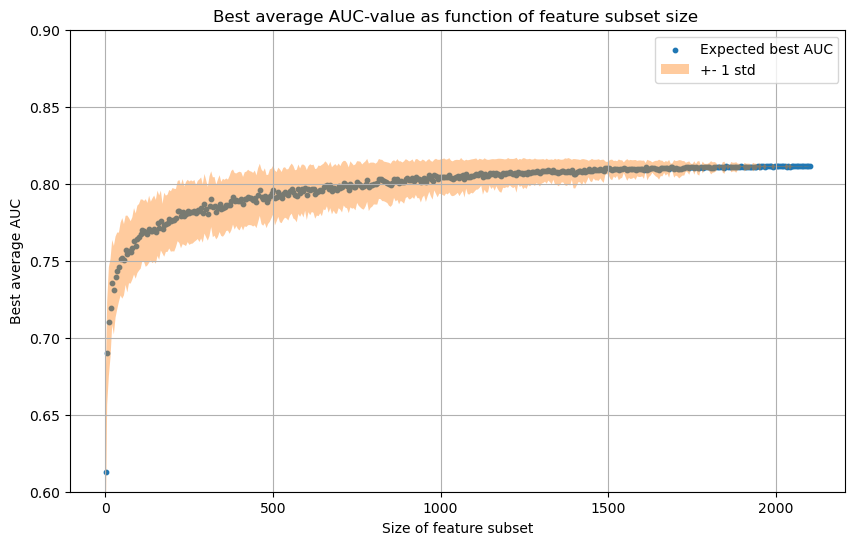

In [ ]:
"""
Plot the best AUC-value as a function of feature subset size investigated. Average over a 100 repetitions
"""

AUC_values = np.array(average_auc_per_feature)

N_values = np.arange(1, 2102, 5)

mean_best_AUC = []
std_best_AUC = []

N_repetitions = 100

for N in N_values:
    best_AUCs = []
    for _ in range(N_repetitions):
        subset_idx = np.random.choice(len(AUC_values), size=N, replace=False)
        subset_AUCS = AUC_values[subset_idx]
        best_AUC = np.max(subset_AUCS)
        best_AUCs.append(best_AUC)

    mean_best_AUC.append(np.mean(best_AUCs))
    std_best_AUC.append(np.std(best_AUCs))

mean_best_AUC = np.array(mean_best_AUC)
std_best_AUC = np.array(std_best_AUC)

plt.figure(figsize=(10, 6))

plt.scatter(N_values, mean_best_AUC, s = 10, label = "Expected best AUC")
plt.fill_between(N_values, mean_best_AUC - std_best_AUC, mean_best_AUC + std_best_AUC, alpha = 0.4, label = "+- 1 std")

plt.xlabel("Size of feature subset")
plt.ylabel("Best average AUC")
plt.title("Best average AUC-value as function of feature subset size ")

plt.ylim(0.6, 0.9)

plt.grid()
plt.legend()
plt.show()

In [ ]:
"""
Computes the AUC-value for all possible combinations of features from two features in combinations to ten features in combination. 
Run classifier with the features with highest individual AUC (2 vs 2, 3 vs 3, ... all 10)
Obtains the overall best AUC-values, and the best AUC-value for each subset size
Author: Anne Louise Kristoffersen
Script modified by me to fit my data 
"""

tot_stats = X 
labels = y 

le = LabelEncoder()
labels_encoded = le.fit_transform(labels)

print(tot_stats.shape)
print(labels_encoded.shape)
print(np.unique(labels_encoded, return_counts=True))


highest_auc_features = best_feature_indices

results=[]
best_by_k = {}  

for k in range(2, len(highest_auc_features)+1): 
    for subset in combinations(highest_auc_features, k):
        # Choose features to look at
        subject_vectors = tot_stats[:,subset]
        
        #### ===== Set up 5-fold CV =====
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

        y_num = labels_encoded

        classes_all = np.unique(y_num)

        # For storing AUC+accuracy and plotting 
        accuracies=[]
        aucs=[]

        # 5-fold cross-validation
        for i, (train_idx, test_idx) in enumerate(cv.split(subject_vectors, y_num), start=1):

            # Split data in training and test set
            X_train, X_test = subject_vectors[train_idx], subject_vectors[test_idx]
            y_train, y_test = y_num[train_idx], y_num[test_idx]

            clf = make_pipeline(
                StandardScaler(),
                SVC(
                    kernel="linear",
                    probability=True,
                    decision_function_shape="ovo",
                    random_state=42
                )
            )

            clf.fit(X_train, y_train)

            # === Accuracy ===
            #y_pred = clf_ovr.predict(X_test)
            y_pred = clf.predict(X_test)
            acc = accuracy_score(y_test, y_pred)
            accuracies.append(acc)

            # === AUC ===
            y_score = clf.predict_proba(X_test)

            roc_auc_i = roc_auc_score(
                y_test,
                y_score,
                multi_class="ovo",
                average="macro",
                labels=classes_all
            )

            aucs.append(roc_auc_i)

    
        current = {'features': subset, 'accuracy': np.mean(accuracies), 'auc': np.mean(aucs),} 
            
        k = len(subset)
        if k not in best_by_k:
            best_by_k[k] = current
        else:
            prev = best_by_k[k]
            # Primary: higher AUC; tie-breaker: higher accuracy
            if (current['auc'] > prev['auc']) or (np.isclose(current['auc'], prev['auc']) and current['accuracy'] > prev['accuracy']):
                best_by_k[k] = current

        results.append({
            'features': subset,
            'accuracy': np.mean(accuracies),
            'auc': np.mean(aucs),
        })

## ==== Print best results ====
# Sort results by AUC
results_sorted = sorted(results, key=lambda x: (x['auc'], x['accuracy']), reverse=True)

# Example: print top 5
for r in results_sorted[:5]:
    print(r)


# After loops:
print("\n=== Best subset per k (by AUC, tiebreak accuracy) ===")
for k in sorted(best_by_k):
    r = best_by_k[k]
    print(f"k={k} | ACC={r['accuracy']:.3f} | AUC={r['auc']:.3f} | features={tuple(r['features'])}")

(32, 2114)
(32,)
(array([0, 1, 2]), array([ 9, 14,  9]))
{'features': (1657, 295, 316, 1044, 1530), 'accuracy': np.float64(0.8761904761904763), 'auc': np.float64(1.0)}
{'features': (1657, 1283, 316, 2011, 1044), 'accuracy': np.float64(0.8761904761904763), 'auc': np.float64(1.0)}
{'features': (1657, 1283, 316, 2011, 440, 1044), 'accuracy': np.float64(0.8761904761904763), 'auc': np.float64(1.0)}
{'features': (1657, 491, 1283, 316, 2011, 1044), 'accuracy': np.float64(0.8428571428571429), 'auc': np.float64(1.0)}
{'features': (295, 491, 1825, 316, 2011, 1044), 'accuracy': np.float64(0.8761904761904763), 'auc': np.float64(0.9944444444444445)}

=== Best subset per k (by AUC, tiebreak accuracy) ===
k=2 | ACC=0.724 | AUC=0.950 | features=(1657, 295)
k=3 | ACC=0.748 | AUC=0.969 | features=(1657, 295, 1044)
k=4 | ACC=0.776 | AUC=0.994 | features=(1657, 316, 2011, 1044)
k=5 | ACC=0.876 | AUC=1.000 | features=(1657, 295, 316, 1044, 1530)
k=6 | ACC=0.876 | AUC=1.000 | features=(1657, 1283, 316, 2011

   Rank  Gaussian mean AUC  Gaussian 5th percentile  Gaussian 95th percentile
0     1           0.821931                 0.792754                  0.864859
1     2           0.805623                 0.785611                  0.835420
2     3           0.796434                 0.780041                  0.819150
3     4           0.790841                 0.772766                  0.810494
4     5           0.785285                 0.769503                  0.802807
5     6           0.780312                 0.767416                  0.797237
6     7           0.776770                 0.763360                  0.792813
7     8           0.773936                 0.761905                  0.787287
8     9           0.771355                 0.758951                  0.784039
9    10           0.768439                 0.755717                  0.781335


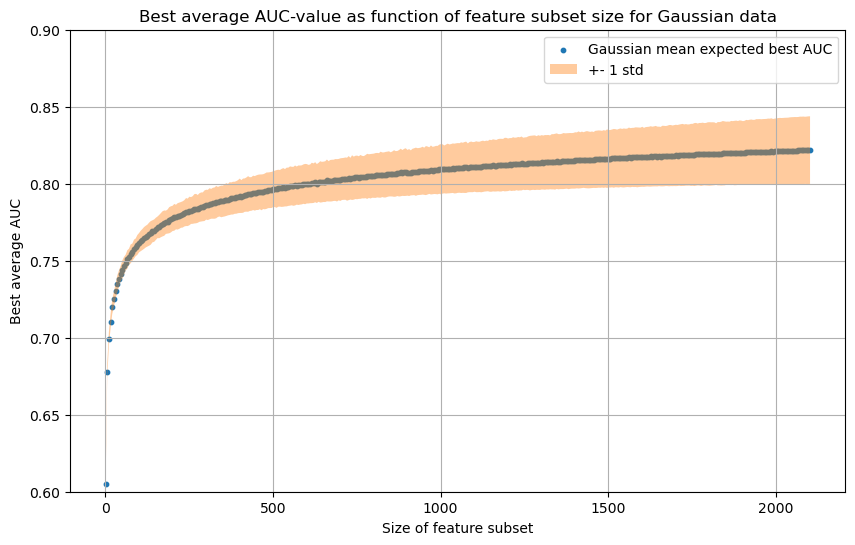

In [ ]:
"""
Plot the best AUC-value as a function of feature subset size investigated for Gaussian-distributed simulated data. Average over a 100 simulation with 100 repetitions in each simulation.
Obtains the ten best average AUC-values across simulations
"""

n_sim = 100
N_repetitions = 100
N_values = np.arange(1, 2102, 5)
gaussian_top10_all = []
mean_best_AUC = []
all_sim_curves = []

y = np.array([0, 1, 1, 1, 2, 2, 1, 1, 0, 1, 2, 2, 1, 1, 1, 2, 0, 0, 2, 0, 0, 0, 2, 0, 1, 0, 1, 1, 2, 2, 1, 1])
classes = np.unique(y)

for s in range(n_sim):
    X_rand = np.random.normal(loc=0, scale=1, size=(32, 2114))
    average_auc_per_feature = [] 
    for k in range(X_rand.shape[1]): 
            X_column = X_rand[:, k] 
            aucs = []
            for i in range(len(classes)):
                    for j in range(i + 1, len(classes)):
                            c1, c2 = classes[i], classes[j]
                            
                            mask = (y == c1) | (y == c2)
                            y_pair = y[mask]
                            X_pair = X_column[mask]
                            
                            # binary labels: c2 = 1, c1 = 0
                            y_bin = (y_pair == c2).astype(int)
                            
                            auc = roc_auc_score(y_bin, X_pair)
                            auc = max(auc, 1 - auc)
                            aucs.append(auc)

            average_auc = np.mean(aucs)
            average_auc_per_feature.append(average_auc)
            #print("Pairwise AUCs:", aucs)

    AUC_values = np.array(average_auc_per_feature)

    sorted_aucs= np.sort(AUC_values)[::-1]
    top10 = sorted_aucs[:10]
    gaussian_top10_all.append(top10)

    mean_best_AUC = []

    for N in N_values:
        best_AUCs = []
        for _ in range(N_repetitions):
            subset_idx = np.random.choice(len(AUC_values), size=N, replace=False)
            subset_AUCS = AUC_values[subset_idx]
            best_AUC = np.max(subset_AUCS)
            best_AUCs.append(best_AUC)

        mean_best_AUC.append(np.mean(best_AUCs))
    
    all_sim_curves.append(mean_best_AUC)

gaussian_top10_all = np.array(gaussian_top10_all)
all_sim_curves = np.array(all_sim_curves)


gaussian_top_10_summary = pd.DataFrame({
       "Rank": np.arange(1, 11),
       "Gaussian mean AUC": np.mean(gaussian_top10_all, axis=0),
       "Gaussian 5th percentile": np.percentile(gaussian_top10_all, 5, axis=0),
       "Gaussian 95th percentile": np.percentile(gaussian_top10_all, 95, axis=0)
})

print(gaussian_top_10_summary)

mean_curve = np.mean(all_sim_curves, axis=0)
std_curve = np.std(all_sim_curves, axis=0)

plt.figure(figsize=(10, 6))

plt.scatter(N_values, mean_curve, s= 10, label="Gaussian mean expected best AUC")
plt.fill_between(N_values, mean_curve - std_curve, mean_curve + std_curve, alpha = 0.4, label = "+- 1 std")

plt.xlabel("Size of feature subset")
plt.ylabel("Best average AUC")
plt.title("Best average AUC-value as function of feature subset size for Gaussian data")
plt.ylim(0.6, 0.9)
plt.grid()
plt.legend()
plt.show()

In [ ]:
"""
Computes the AUC-value for all possible combinations of features from two features in combinations to ten features in combination for Gaussian-distributed simulated data. 
Run classifier with the features with highest individual AUC (2 vs 2, 3 vs 3, ... all 10)
Obtains the overall best AUC-values, and the best AUC-value for each subset size
Author: Anne Louise Kristoffersen
Script modified by me to fit my data 
"""

X_gaussian = np.random.normal(loc=0, scale=1, size=(32, 2114))

y = np.array([0, 1, 1, 1, 2, 2, 1, 1, 0, 1, 2, 2, 1, 1, 1, 2, 0, 0, 2, 0, 0, 0, 2, 0, 1, 0, 1, 1, 2, 2, 1, 1])
classes = np.unique(y)
average_auc_per_feature_gaussian = [] 

for k in range(X_gaussian.shape[1]): 
        X_column = X_gaussian[:, k] 
        aucs = []
        for i in range(len(classes)):
                for j in range(i + 1, len(classes)):
                        c1, c2 = classes[i], classes[j]
                        
                        mask = (y == c1) | (y == c2)
                        y_pair = y[mask]
                        X_pair = X_column[mask]
                        
                        # binary labels: c2 = 1, c1 = 0
                        y_bin = (y_pair == c2).astype(int)
                        
                        auc = roc_auc_score(y_bin, X_pair)
                        auc = max(auc, 1 - auc)
                        aucs.append(auc)

        average_auc = np.mean(aucs)
        average_auc_per_feature_gaussian.append(average_auc)
        #print("Pairwise AUCs:", aucs)


print("Average AUC per feature", average_auc_per_feature_gaussian)

auc_results_gaussian = pd.DataFrame({
      "Feature": X_df_clean.columns,
      "AUC": average_auc_per_feature_gaussian
})

auc_results_gaussian = auc_results_gaussian.sort_values(by="AUC", ascending=False)

top10_gaussian = auc_results_gaussian.head(10)
print(top10_gaussian)

best_feature_indices_gaussian = top10_gaussian.index.tolist()
print(best_feature_indices_gaussian)

tot_stats = X_gaussian
labels = y 

le = LabelEncoder()
labels_encoded = le.fit_transform(labels)

print(tot_stats.shape)
print(labels_encoded.shape)
print(np.unique(labels_encoded, return_counts=True))


highest_auc_features = best_feature_indices_gaussian

results=[]
best_by_k = {}  

for k in range(2, len(highest_auc_features)+1): 
    for subset in combinations(highest_auc_features, k):
        # Choose features to look at
        subject_vectors = tot_stats[:,subset]
        
        #### ===== Set up 5-fold CV =====
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

        y_num = labels_encoded

        classes_all = np.unique(y_num)

        # For storing AUC+accuracy and plotting 
        accuracies=[]
        aucs=[]

        # 5-fold cross-validation
        for i, (train_idx, test_idx) in enumerate(cv.split(subject_vectors, y_num), start=1):

            # Split data in training and test set
            X_train, X_test = subject_vectors[train_idx], subject_vectors[test_idx]
            y_train, y_test = y_num[train_idx], y_num[test_idx]

            clf = make_pipeline(
                StandardScaler(),
                SVC(
                    kernel="linear",
                    probability=True,
                    decision_function_shape="ovo",
                    random_state=42
                )
            )

            clf.fit(X_train, y_train)

            # === Accuracy ===
            #y_pred = clf_ovr.predict(X_test)
            y_pred = clf.predict(X_test)
            acc = accuracy_score(y_test, y_pred)
            accuracies.append(acc)

            # === AUC ===
            y_score = clf.predict_proba(X_test)

            roc_auc_i = roc_auc_score(
                y_test,
                y_score,
                multi_class="ovo",
                average="macro",
                labels=classes_all
            )

            aucs.append(roc_auc_i)

    
        current = {'features': subset, 'accuracy': np.mean(accuracies), 'auc': np.mean(aucs),} 
            
        k = len(subset)
        if k not in best_by_k:
            best_by_k[k] = current
        else:
            prev = best_by_k[k]
            # Primary: higher AUC; tie-breaker: higher accuracy
            if (current['auc'] > prev['auc']) or (np.isclose(current['auc'], prev['auc']) and current['accuracy'] > prev['accuracy']):
                best_by_k[k] = current

        results.append({
            'features': subset,
            'accuracy': np.mean(accuracies),
            'auc': np.mean(aucs),
        })

## ==== Print best results ====
# Sort results by AUC
results_sorted = sorted(results, key=lambda x: (x['auc'], x['accuracy']), reverse=True)

# Example: print top 5
for r in results_sorted[:5]:
    print(r)


# After loops:
print("\n=== Best subset per k (by AUC, tiebreak accuracy) ===")
for k in sorted(best_by_k):
    r = best_by_k[k]
    print(f"k={k} | ACC={r['accuracy']:.3f} | AUC={r['auc']:.3f} | features={tuple(r['features'])}")

Average AUC per feature [np.float64(0.6134626690182245), np.float64(0.533803644914756), np.float64(0.5379188712522045), np.float64(0.6387419165196943), np.float64(0.6957671957671957), np.float64(0.5532039976484421), np.float64(0.5670194003527337), np.float64(0.6252204585537918), np.float64(0.549970605526161), np.float64(0.6199294532627866), np.float64(0.6058201058201059), np.float64(0.6516754850088183), np.float64(0.6393298059964727), np.float64(0.5626102292768959), np.float64(0.6490299823633158), np.float64(0.6149323927101705), np.float64(0.6651969429747208), np.float64(0.5470311581422692), np.float64(0.6281599059376837), np.float64(0.5693709582598472), np.float64(0.5714285714285715), np.float64(0.6375661375661376), np.float64(0.5787771898883011), np.float64(0.5629041740152851), np.float64(0.5567313345091123), np.float64(0.6437389770723104), np.float64(0.5955320399764844), np.float64(0.5940623162845385), np.float64(0.537037037037037), np.float64(0.6019988242210464), np.float64(0.56878

   Rank  Feature-wise permutation mean AUC  \
0     1                           0.822127   
1     2                           0.803445   
2     3                           0.792741   
3     4                           0.785873   
4     5                           0.781264   
5     6                           0.777111   
6     7                           0.773698   
7     8                           0.770647   
8     9                           0.767964   
9    10                           0.765619   

   Feature-wise permutation 5th percentile  \
0                                 0.793269   
1                                 0.783892   
2                                 0.774243   
3                                 0.767909   
4                                 0.766792   
5                                 0.763272   
6                                 0.761214   
7                                 0.757922   
8                                 0.756599   
9                                

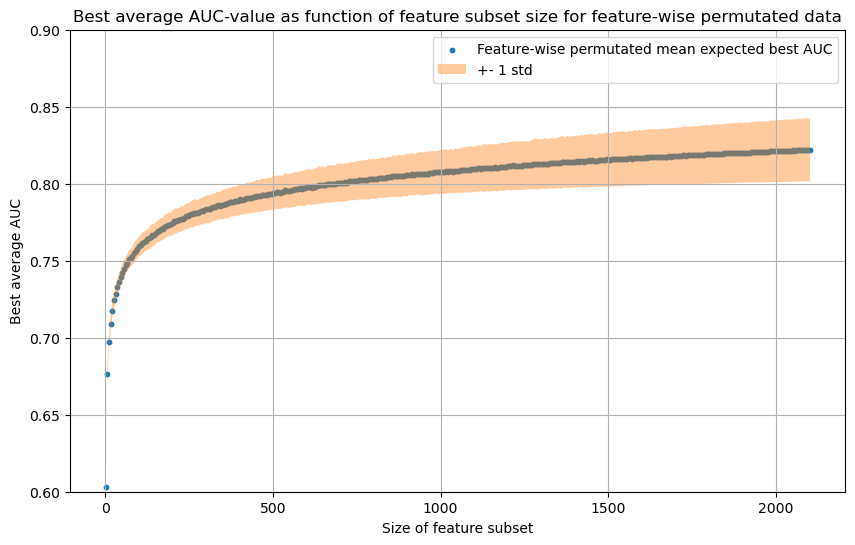

In [ ]:
"""
Plot the best AUC-value as a function of feature subset size investigated for feature-wise permutated data. Average over a 100 simulation with 100 repetitions in each simulation.
Obtains the ten best average AUC-values across simulations
"""

n_sim = 100
N_repetitions = 100
N_values = np.arange(1, 2102, 5)
permutation_top10_all = []
mean_best_AUC = []
all_sim_curves = []

y = np.array([0, 1, 1, 1, 2, 2, 1, 1, 0, 1, 2, 2, 1, 1, 1, 2, 0, 0, 2, 0, 0, 0, 2, 0, 1, 0, 1, 1, 2, 2, 1, 1])
classes = np.unique(y)

for s in range(n_sim):
    X_permutation = np.zeros_like(X)
    for k in range(X.shape[1]):
        X_permutation[:, k] = np.random.permutation(X[:, k])
    average_auc_per_feature = [] 
    for k in range(X_permutation.shape[1]): 
            X_column = X_permutation[:, k] 
            aucs = []
            for i in range(len(classes)):
                    for j in range(i + 1, len(classes)):
                            c1, c2 = classes[i], classes[j]
                            
                            mask = (y == c1) | (y == c2)
                            y_pair = y[mask]
                            X_pair = X_column[mask]
                            
                            # binary labels: c2 = 1, c1 = 0
                            y_bin = (y_pair == c2).astype(int)
                            
                            auc = roc_auc_score(y_bin, X_pair)
                            auc = max(auc, 1 - auc)
                            aucs.append(auc)

            average_auc = np.mean(aucs)
            average_auc_per_feature.append(average_auc)
            #print("Pairwise AUCs:", aucs)

    AUC_values = np.array(average_auc_per_feature)

    sorted_aucs= np.sort(AUC_values)[::-1]
    top10 = sorted_aucs[:10]
    permutation_top10_all.append(top10)

    mean_best_AUC = []

    for N in N_values:
        best_AUCs = []
        for _ in range(N_repetitions):
            subset_idx = np.random.choice(len(AUC_values), size=N, replace=False)
            subset_AUCS = AUC_values[subset_idx]
            best_AUC = np.max(subset_AUCS)
            best_AUCs.append(best_AUC)

        mean_best_AUC.append(np.mean(best_AUCs))
    
    all_sim_curves.append(mean_best_AUC)

permutation_top10_all = np.array(permutation_top10_all)
all_sim_curves = np.array(all_sim_curves)

permutation_top_10_summary = pd.DataFrame({
       "Rank": np.arange(1, 11),
       "Feature-wise permutation mean AUC": np.mean(permutation_top10_all, axis=0),
       "Feature-wise permutation 5th percentile": np.percentile(permutation_top10_all, 5, axis=0),
       "Feature-wise permutation 95th percentile": np.percentile(permutation_top10_all, 95, axis=0)
})

print(permutation_top_10_summary)

mean_curve = np.mean(all_sim_curves, axis=0)
std_curve = np.std(all_sim_curves, axis=0)

plt.figure(figsize=(10, 6))

plt.scatter(N_values, mean_curve, s= 10, label="Feature-wise permutated mean expected best AUC")
plt.fill_between(N_values, mean_curve - std_curve, mean_curve + std_curve, alpha = 0.4, label = "+- 1 std")

plt.xlabel("Size of feature subset")
plt.ylabel("Best average AUC")
plt.title("Best average AUC-value as function of feature subset size for feature-wise permutated data")
plt.ylim(0.6, 0.9)
plt.grid()
plt.legend()
plt.show()

In [ ]:
"""
Computes the AUC-value for all possible combinations of features from two features in combinations to ten features in combination for feature-wise permutated data. 
Run classifier with the features with highest individual AUC (2 vs 2, 3 vs 3, ... all 10)
Obtains the overall best AUC-values, and the best AUC-value for each subset size
Author: Anne Louise Kristoffersen
Script modified by me to fit my data 
"""

X_permutation = np.zeros_like(X)
for k in range(X.shape[1]):
    X_permutation[:, k] = np.random.permutation(X[:, k])

y = np.array([0, 1, 1, 1, 2, 2, 1, 1, 0, 1, 2, 2, 1, 1, 1, 2, 0, 0, 2, 0, 0, 0, 2, 0, 1, 0, 1, 1, 2, 2, 1, 1])
classes = np.unique(y)
average_auc_per_feature_permutation = [] 

for k in range(X_permutation.shape[1]): 
        X_column = X_permutation[:, k] 
        aucs = []
        for i in range(len(classes)):
                for j in range(i + 1, len(classes)):
                        c1, c2 = classes[i], classes[j]
                        
                        mask = (y == c1) | (y == c2)
                        y_pair = y[mask]
                        X_pair = X_column[mask]
                        
                        # binary labels: c2 = 1, c1 = 0
                        y_bin = (y_pair == c2).astype(int)
                        
                        auc = roc_auc_score(y_bin, X_pair)
                        auc = max(auc, 1 - auc)
                        aucs.append(auc)

        average_auc = np.mean(aucs)
        average_auc_per_feature_permutation.append(average_auc)
        #print("Pairwise AUCs:", aucs)


print("Average AUC per feature", average_auc_per_feature_permutation)

auc_results_permutation = pd.DataFrame({
      "Feature": X_df_clean.columns,
      "AUC": average_auc_per_feature_permutation
})

auc_results_permutation = auc_results_permutation.sort_values(by="AUC", ascending=False)

top10_permutation = auc_results_permutation.head(10)
print(top10_permutation)

best_feature_indices_permutation = top10_permutation.index.tolist()
print(best_feature_indices_permutation)

tot_stats = X_permutation
labels = y 

le = LabelEncoder()
labels_encoded = le.fit_transform(labels)

print(tot_stats.shape)
print(labels_encoded.shape)
print(np.unique(labels_encoded, return_counts=True))


highest_auc_features = best_feature_indices_permutation

results=[]
best_by_k = {}  

for k in range(2, len(highest_auc_features)+1): 
    for subset in combinations(highest_auc_features, k):
        # Choose features to look at
        subject_vectors = tot_stats[:,subset]
        
        #### ===== Set up 5-fold CV =====
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

        y_num = labels_encoded

        classes_all = np.unique(y_num)

        # For storing AUC+accuracy and plotting 
        accuracies=[]
        aucs=[]

        # 5-fold cross-validation
        for i, (train_idx, test_idx) in enumerate(cv.split(subject_vectors, y_num), start=1):

            # Split data in training and test set
            X_train, X_test = subject_vectors[train_idx], subject_vectors[test_idx]
            y_train, y_test = y_num[train_idx], y_num[test_idx]

            clf = make_pipeline(
                StandardScaler(),
                SVC(
                    kernel="linear",
                    probability=True,
                    decision_function_shape="ovo",
                    random_state=42
                )
            )

            clf.fit(X_train, y_train)

            # === Accuracy ===
            #y_pred = clf_ovr.predict(X_test)
            y_pred = clf.predict(X_test)
            acc = accuracy_score(y_test, y_pred)
            accuracies.append(acc)

            # === AUC ===
            y_score = clf.predict_proba(X_test)

            roc_auc_i = roc_auc_score(
                y_test,
                y_score,
                multi_class="ovo",
                average="macro",
                labels=classes_all
            )

            aucs.append(roc_auc_i)

    
        current = {'features': subset, 'accuracy': np.mean(accuracies), 'auc': np.mean(aucs),} 
     
        k = len(subset)
        if k not in best_by_k:
            best_by_k[k] = current
        else:
            prev = best_by_k[k]
            # Primary: higher AUC; tie-breaker: higher accuracy
            if (current['auc'] > prev['auc']) or (np.isclose(current['auc'], prev['auc']) and current['accuracy'] > prev['accuracy']):
                best_by_k[k] = current

        results.append({
            'features': subset,
            'accuracy': np.mean(accuracies),
            'auc': np.mean(aucs),
        })

## ==== Print best results ====
# Sort results by AUC
results_sorted = sorted(results, key=lambda x: (x['auc'], x['accuracy']), reverse=True)

# Example: print top 5
for r in results_sorted[:5]:
    print(r)


# After loops:
print("\n=== Best subset per k (by AUC, tiebreak accuracy) ===")
for k in sorted(best_by_k):
    r = best_by_k[k]
    print(f"k={k} | ACC={r['accuracy']:.3f} | AUC={r['auc']:.3f} | features={tuple(r['features'])}")

Average AUC per feature [np.float64(0.5811287477954145), np.float64(0.5470311581422692), np.float64(0.5576131687242798), np.float64(0.5784832451499118), np.float64(0.5649617871840095), np.float64(0.7034097589653147), np.float64(0.562904174015285), np.float64(0.5587889476778366), np.float64(0.5314520870076426), np.float64(0.5532039976484421), np.float64(0.6072898295120518), np.float64(0.6140505584950029), np.float64(0.6067019400352734), np.float64(0.5990593768371546), np.float64(0.5238095238095238), np.float64(0.5205761316872428), np.float64(0.5626102292768959), np.float64(0.6119929453262787), np.float64(0.5911228689006467), np.float64(0.6108171663727219), np.float64(0.5878894767783657), np.float64(0.5452674897119342), np.float64(0.6072898295120518), np.float64(0.6569664902998237), np.float64(0.6017048794826573), np.float64(0.6405055849500294), np.float64(0.7104644326866548), np.float64(0.5664315108759553), np.float64(0.5357142857142857), np.float64(0.5246913580246914), np.float64(0.554

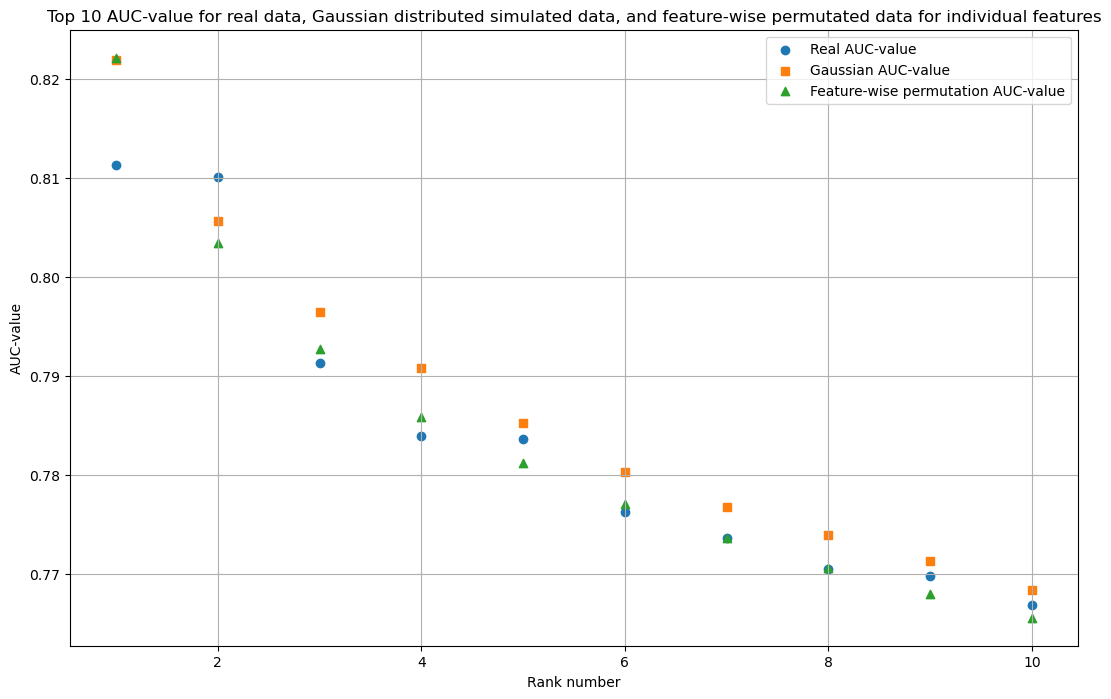

In [ ]:
"""
Plot the top ten AUC-values for individual features for the real dataset, Gaussian-distributed simulated dataset, and the feature-wise permutated dataset
"""

rank = np.arange(1, 11)

real_AUC = [0.811287, 0.810112, 0.791299, 0.783951, 0.783657, 0.776308, 0.773663, 0.770576, 0.769841, 0.766902]

gaussian_AUC = [0.821931, 0.805623, 0.796434, 0.790841, 0.785285, 0.780312, 0.776770, 0.773936, 0.771355, 0.768439]

feature_wise_AUC = [0.822127, 0.803445, 0.792741, 0.785873, 0.781264, 0.777111, 0.773698, 0.770647, 0.767964, 0.765619]

plt.figure(figsize=(13, 8))

plt.scatter(rank, real_AUC, marker="o", label="Real AUC-value")
plt.scatter(rank, gaussian_AUC, marker="s", label="Gaussian AUC-value")
plt.scatter(rank, feature_wise_AUC, marker="^", label="Feature-wise permutation AUC-value")

plt.xlabel("Rank number")
plt.ylabel("AUC-value")
plt.title("Top 10 AUC-value for real data, Gaussian distributed simulated data, and feature-wise permutated data for individual features")
plt.grid()
plt.legend()
plt.show()

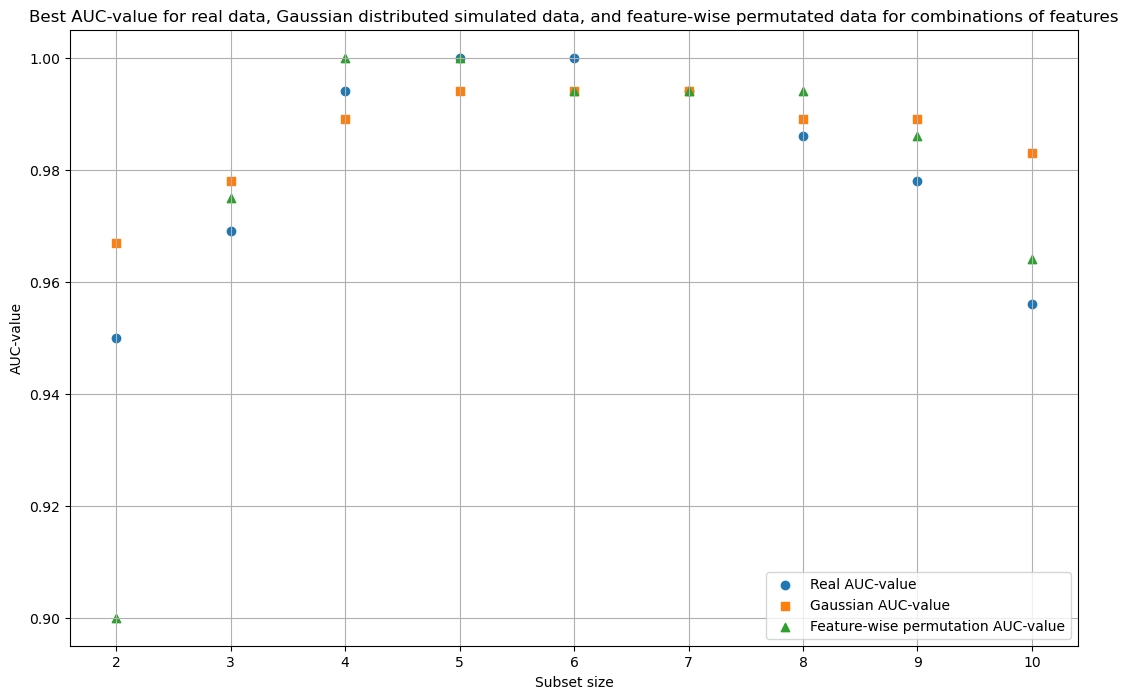

In [ ]:
"""
Plot the best AUC-value for each feature subset size (number of features looked at in combinations) for the real dataset, Gaussian-distributed simulated dataset, and the feature-wise permutated dataset
"""

subset_size = np.arange(2, 11)

real_AUC = [0.950, 0.969, 0.994, 1.000, 1.000, 0.994, 0.986, 0.978, 0.956]

gaussian_AUC = [0.967, 0.978, 0.989, 0.994, 0.994, 0.994, 0.989, 0.989, 0.983]

feature_wise_AUC = [0.900, 0.975, 1.000, 1.000, 0.994, 0.994, 0.994, 0.986, 0.964]

plt.figure(figsize=(13, 8))

plt.scatter(subset_size, real_AUC, marker="o", label="Real AUC-value")
plt.scatter(subset_size, gaussian_AUC, marker="s", label="Gaussian AUC-value")
plt.scatter(subset_size, feature_wise_AUC, marker="^", label="Feature-wise permutation AUC-value")

plt.xlabel("Subset size")
plt.ylabel("AUC-value")
plt.title("Best AUC-value for real data, Gaussian distributed simulated data, and feature-wise permutated data for combinations of features")
plt.grid()
plt.legend()
plt.show()